# MNIST Deep Neural Network

Handwritten digit classifier built from scratch in NumPy — no high-level ML frameworks.

**Architecture:** `784 inputs → tanh hidden layer (100 neurons) → dropout → softmax → 10 classes`

**Techniques:** Mini-batch gradient descent · Dropout regularisation · Tanh + Softmax activations · One-hot encoding · MSE loss

**Results:** 97.8% test accuracy on 10,000 unseen images after 200 training iterations using mini-batch gradient descent (batch size 100, alpha 0.06, 75% dropout keep rate). Train/test gap of only ~0.2%, indicating the network generalises well rather than memorising the training data.


First Step: Getting the data: 
For this we are going to use keras the api for tensor flow to get our dataset. 

In [84]:
# import dataset
from keras.datasets import mnist

# import numpy and matplotlib 
import numpy as np
import matplotlib.pyplot as plt

# for cleaner outputs
import sys

---
## Loading the Data

`mnist.load_data()` returns two tuples — one for training, one for testing:

- **`x_train`** — a 3D NumPy array of shape `(60000, 28, 28)`: 60,000 images, each a 28×28 grid of pixel values (0–255)
- **`y_train`** — a 1D array of shape `(60000,)`: the correct digit label (0–9) for each training image
- **`x_test`** / **`y_test`** — same structure but 10,000 images, kept separate to evaluate the trained network

So `x_train[0]` is the first image (a 28×28 array of numbers) and `y_train[0]` is the digit it shows.

x_train = [   
      [[...28 pixels...], [...28 pixels...], ... 28 rows],  ← image 0                                                    
      [[...28 pixels...], [...28 pixels...], ... 28 rows],  ← image 1                                                    
      ...                                                                                                                
      [[...28 pixels...], [...28 pixels...], ... 28 rows],  ← image 59,999                                               
  ]                                                                                                                      
   
  60,000 "rows", each one being a complete image represented as a 28×28 array.   

In [85]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

training_image_count, training_image_height, training_image_width = x_train.shape[0], x_train.shape[1], x_train.shape[2]
training_label_count, training_label_dtype = y_train.shape[0], y_train.dtype
print(f"Training Data:")
print(f"Training Images: {training_image_count}")
print(f"Each image is {training_image_height} x {training_image_width} pixels; totaling {training_image_height * training_image_width} pixels")
print(f"Training Labels: {training_label_count}")
print(f"Each label is a single integer (0–9), dtype: {training_label_dtype}")

test_image_count, test_image_height, test_image_width = x_test.shape[0], x_test.shape[1], x_test.shape[2]
test_label_count, test_label_dtype = y_test.shape[0], y_test.dtype
print(f"\nTest Data:")
print(f"Test Images: {test_image_count}")
print(f"Each image is {test_image_height} x {test_image_width} pixels; totaling {test_image_height * test_image_width} pixels")
print(f"Test Labels: {test_label_count}")
print(f"Each label is a single integer (0–9), dtype: {test_label_dtype}")

Training Data:
Training Images: 60000
Each image is 28 x 28 pixels; totaling 784 pixels
Training Labels: 60000
Each label is a single integer (0–9), dtype: uint8

Test Data:
Test Images: 10000
Each image is 28 x 28 pixels; totaling 784 pixels
Test Labels: 10000
Each label is a single integer (0–9), dtype: uint8


---
## Helper Functions

In [86]:
# ── 1. Visualise a single image and its label ─────────────────────────────
def visualize_image_and_label(index, train=True):

    # pick the right dataset based on the train flag
    if train:
        image = x_train[index]   # shape: (28, 28)
        label = y_train[index]   # single integer 0-9
        split = "Train"
    else:
        image = x_test[index]
        label = y_test[index]
        split = "Test"

    plt.figure(figsize=(3, 3))
    plt.imshow(image, cmap='gray')
    plt.title(f"{split} Image {index} — Label: {label}")
    plt.axis('off')
    plt.show()


# ── 2. Visualise a grid of random images ──────────────────────────────────
def visualize_grid(n=10, train=True):
    images = x_train if train else x_test
    labels = y_train if train else y_test

    # pick n random indices from the dataset
    indices = np.random.randint(0, len(images), n)

    # create a row of n subplots side by side
    fig, axes = plt.subplots(1, n, figsize=(n * 1.5, 2))

    for ax, idx in zip(axes, indices):
        ax.imshow(images[idx], cmap='gray')
        ax.set_title(str(labels[idx]))  # show the digit label above each image
        ax.axis('off')

    plt.suptitle("Random sample from dataset", y=1.05)
    plt.tight_layout()
    plt.show()


# ── 3. Visualise learned weights as 28×28 images ──────────────────────────
def visualize_weights(weights_0_1, n=16):
    # weights_0_1 is (784, hidden_size) — each COLUMN is one neuron's weights
    # we take the first n neurons and reshape each from 784 → 28×28

    cols = 8
    rows = n // cols  # how many rows we need in the grid

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.5, rows * 1.5))

    for i, ax in enumerate(axes.flat):
        # reshape the 784 weights for neuron i into a 28×28 image
        weight_image = weights_0_1[:, i].reshape(28, 28)
        ax.imshow(weight_image, cmap='bwr')  # bwr = blue-white-red: neg=blue, pos=red
        ax.axis('off')

    plt.suptitle("Learned weight patterns (one per hidden neuron)", y=1.02)
    plt.tight_layout()
    plt.show()


# ── 4. Visualise a dropout mask ───────────────────────────────────────────
def visualize_dropout_mask(mask):
    # mask is (input_size, hidden_size) — 1 = neuron active, 0 = neuron dropped
    # we display it as a black and white image
    # white pixels = active connections, black pixels = dropped connections

    plt.figure(figsize=(8, 3))
    plt.imshow(mask.T, cmap='gray', aspect='auto')  # transpose so neurons are rows
    plt.title("Dropout mask — white=active, black=dropped")
    plt.xlabel("Input pixels (784)")
    plt.ylabel("Hidden neurons (100)")
    plt.colorbar()
    plt.show()


# ── 5. Plot an activation function curve ──────────────────────────────────
def plot_activation(fn, name):
    # generate 200 evenly spaced values between -6 and 6
    x = np.linspace(-6, 6, 200)
    y = fn(x)

    plt.figure(figsize=(6, 3))
    plt.plot(x, y, label=name)
    plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')  # horizontal zero line
    plt.axvline(0, color='gray', linewidth=0.8, linestyle='--')  # vertical zero line
    plt.title(f"Activation function: {name}")
    plt.xlabel("Input value")
    plt.ylabel("Output value")
    plt.legend()
    plt.tight_layout()
    plt.show()


# ── 6. Visualise a prediction after training ──────────────────────────────
def visualize_prediction(index, train=False):
    # pick image and run a forward pass through the trained network
    images = x_train if train else x_test
    labels = y_train if train else y_test

    image = images[index]
    true_label = labels[index]

    # flatten the 28×28 image to a (1, 784) row and normalise pixels to 0–1
    layer_0 = image.flatten() / 255.0
    layer_0 = layer_0.reshape(1, -1)

    # forward pass (no dropout at inference time)
    layer_1 = tanh(np.dot(layer_0, weights_0_1))
    layer_2 = softmax(np.dot(layer_1, weights_1_2))  # shape: (1, 10) — one prob per digit

    probs = layer_2[0]           # pull out the 10 probabilities
    predicted = np.argmax(probs) # digit with highest probability is the prediction

    # plot the image on the left and a bar chart of probabilities on the right
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))

    ax1.imshow(image, cmap='gray')
    ax1.set_title(f"True label: {true_label}  |  Predicted: {predicted}")
    ax1.axis('off')

    # bar chart — green if correct digit, red if wrong
    colours = ['green' if i == true_label else 'steelblue' for i in range(10)]
    ax2.bar(range(10), probs, color=colours)
    ax2.set_xticks(range(10))
    ax2.set_xlabel("Digit")
    ax2.set_ylabel("Probability")
    ax2.set_title("Network output probabilities")

    plt.tight_layout()
    plt.show()


# ── 7. Test 20 random images and show label vs guess ──────────────────────
def test_20_digit(w0, w1, n=20):
    # pick n random indices from the test set
    indices = np.random.randint(0, len(x_test), n)

    cols = 5
    rows = n // cols  # e.g. 20 images → 4 rows of 5

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2.5))

    for ax, idx in zip(axes.flat, indices):
        image = x_test[idx]  # original 28×28 image for display
        true_label = y_test[idx]

        # flatten and normalise for the forward pass
        layer_0 = image.flatten().reshape(1, -1) / 255.0
        layer_1 = tanh(np.dot(layer_0, w0))
        layer_2 = softmax(np.dot(layer_1, w1))
        guess = np.argmax(layer_2)

        # show the image
        ax.imshow(image, cmap='gray')

        # green title if correct, red if wrong
        colour = 'green' if guess == true_label else 'red'
        ax.set_title(f"Label: {true_label}  Guess: {guess}", color=colour, fontsize=8)
        ax.axis('off')

    plt.suptitle("Network predictions on random test images", fontsize=12)
    plt.tight_layout()
    plt.show()


# ── 8. Plot training and test accuracy over iterations ────────────────────
def plot_accuracy(train_accs, test_accs):
    # train_accs and test_accs are lists with one value per iteration
    # e.g. [91.2, 94.6, 95.6, ...] — append to these inside the training loop

    iterations = range(1, len(train_accs) + 1)

    plt.figure(figsize=(8, 4))
    plt.plot(iterations, train_accs, label='Train Accuracy', marker='o')
    plt.plot(iterations, test_accs,  label='Test Accuracy',  marker='o')
    plt.xlabel("Iteration")
    plt.ylabel("Accuracy (%)")
    plt.title("Training vs Test Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def save_weights(weights_0_1, weights_1_2, filename="weights.npz"):
    np.savez(filename, weights_0_1=weights_0_1, weights_1_2=weights_1_2)
    print(f"Weights saved to {filename}")

def load_weights(filename="weights.npz"):
    data = np.load(filename)
    return data["weights_0_1"], data["weights_1_2"]

---
## Network Parameters

Before building the network we define a few key values that control its size and how it learns:

- **`alpha`** — the learning rate. Controls how big a step the network takes when updating its weights. Too high and it overshoots; too low and it learns very slowly.
- **`input_size`** — 784 (28×28). Each image is flattened into a single row of 784 pixel values to feed into the network.
- **`hidden_size`** — 100. The number of neurons in the hidden layer. More neurons = more capacity to learn patterns, but slower to train.
- **`output_size`** — 10. One output neuron per digit (0–9). The network picks whichever has the highest value as its prediction.
- **`iterations`** — how many times the network loops over the entire training set.
- **`batch_size`** — how many images the network processes between weight updates. With `batch_size = 100` and 60,000 training images, each iteration does 600 weight updates (one per batch) instead of 60,000 (one per image). This is much faster because NumPy can process the whole batch as a single matrix operation, and the averaged gradient over a batch is less noisy than the gradient from a single sample.


Creating the network parameters 



In [87]:
# ── Hyperparameters ───────────────────────────────────────────────────────
alpha      = 0.06
input_size = training_image_height * training_image_width # 784
hidden_size = 100
output_size = 10
iterations = 200
batch_size = 100

---
## Activation Functions

**Hidden layer — Tanh**

Tanh squashes any value into the range (−1, 1) and is centred at zero. This is better than ReLU for image data because it produces both positive and negative activations, giving the network a richer signal to learn from. Centring at zero also means gradients stay larger during backpropagation, so the network learns faster.

**Output layer — Softmax**

Softmax is used because we are classifying into exactly one of 10 mutually exclusive categories (digits 0–9). It converts the 10 raw output scores into probabilities that sum to 1 — so the network outputs something like "72% sure this is a 3, 15% sure it's an 8" etc. The digit with the highest probability is taken as the prediction.

In [88]:
def tanh(x):        return np.tanh(x)
def tanh_deriv(o):  return 1 - o ** 2

def softmax(x):
    e = np.exp(x - np.max(x, axis=1, keepdims=True))
    return e / np.sum(e, axis=1, keepdims=True)

## Network Sizes and Weight Shapes

Each image is a 28×28 pixel grid, flattened into a row of **784 numbers** — this is `layer_0`.

The network has two weight matrices:

| Weight matrix | Shape | Why |
|---|---|---|
| `weights_0_1` | (784, 100) | Each of the 784 pixels connects to each of the 100 hidden neurons — one weight per connection |
| `weights_1_2` | (100, 10) | Each of the 100 hidden neurons connects to each of the 10 output neurons (one per digit) |

The shape rule is always `(previous layer size, next layer size)`.

When we compute `layer_0.dot(weights_0_1)` the dimensions are `(1, 784) × (784, 100) = (1, 100)` — the 784s cancel out and we get a row of 100 hidden values. The same pattern repeats for every layer.

Remember: matrices are written as **(rows × columns)**. For two matrices to multiply, the inner dimensions must match — the result takes the outer dimensions.

---

## Initialising Weights with Random Numbers

Weights are initialised randomly using `np.random.random`, which returns values between **0.0 and 1.0**. We shift and scale this range so weights start small and centred near zero — large starting weights cause the network to diverge early in training.

```python
# Range 0.0 → 1.0  (default, too large for weights)
np.random.random((784, 100))

# Range -0.1 → 0.1  (scaled and centred at zero)
np.random.random((784, 100)) * 0.2 - 0.1

# Range -0.01 → 0.01  (narrow range, used for tanh layers)
np.random.random((784, 100)) * 0.02 - 0.01
```

The formula to shift any range is: `random × (max - min) + min`

`np.random.seed(1)` is set before initialising weights so the same random values are generated every run — this makes results reproducible and easier to debug.


### Dropout Mask

A dropout mask is the same shape as the weight matrix between two layers. It randomly switches neurons off during training to prevent the network from relying too heavily on any single neuron — this helps it generalise better.

`np.random.random` gives values between 0.0 and 1.0. Comparing against a threshold with `< 0.5` produces a boolean array (`True`/`False`), which `.astype(int)` converts to `1`s and `0`s:

```python
dropout_mask = (np.random.random((input_size, hidden_size)) < 0.5).astype(int)
```

Multiplying the hidden layer by this mask zeros out ~50% of neurons each forward pass. The threshold controls the **keep rate** — `< 0.5` keeps ~50% active, `< 0.8` keeps ~80%, etc.

You could also write `weights_0_1.shape` instead of `(input_size, hidden_size)` since the mask always needs to match the weight matrix exactly.

In [89]:
# set the random seed to initalize weights randomly. 
np.random.seed(1)

weights_0_1 = np.random.random((input_size, hidden_size)) * 0.02 - 0.01 # this gives a random matrix (784 x 100) of values -0.01 and 0.01
weights_1_2 = np.random.random((hidden_size, output_size)) * 0.2 - 0.1 # this gives a random matrix (100 x 10) of values -0.1, 0.1

---
## Predict, Compare, Learn

Forward propagation is the process of passing an input through the network layer by layer to produce a prediction.
Compare and Learn is the process of figuring out how much each neuron was wrong by and updating the weights to fix the error by propagating it backwards.

Each layer takes the previous layer's output, multiplies it by a weight matrix, and passes the result through an activation function:

1. **layer_0** — the raw input (a flattened, normalised image: 784 numbers)
2. **layer_1** — `tanh(layer_0 · weights_0_1)` — the hidden layer, 100 neurons
3. **layer_2** — `softmax(layer_1 · weights_1_2)` — the output layer, 10 probabilities (one per digit)

The network's prediction is whichever digit has the highest probability in layer_2.

### Mini-batch gradient descent

Instead of updating the weights after every single image (stochastic gradient descent), we group the training data into **batches** of `batch_size` images and do **one weight update per batch**. The forward and backward passes operate on the whole batch as a single matrix operation:

- `layer_0` is now `(batch_size, 784)` instead of `(1, 784)`
- `layer_1` is `(batch_size, 100)` and `layer_2` is `(batch_size, 10)`
- The gradient is **averaged** across the batch (`errors / batch_size`) so the step size doesn't scale with the batch size

This gives three big wins:

1. **Speed** — NumPy does the matrix maths in parallel, so processing 100 images at once is barely slower than processing one
2. **Smoother gradients** — averaging the error across many samples cancels out per-sample noise, giving steadier updates
3. **Fewer total updates per epoch** — 600 updates per iteration instead of 60,000, which means we can crank up `alpha` and run more iterations

After training, the test loop is also vectorised: we run all 10,000 test images through as a single matrix operation since dropout is only applied during training.

**Final result: 97.8% test accuracy after 200 iterations** (batch size 100, alpha 0.06, dropout keep rate 75%).


In [96]:
num_train = 60000
num_test  = 10000

train_images = x_train[0:num_train].reshape(num_train, 28*28) / 255  # flatten and normalise training images
train_labels = y_train[0:num_train]

test_images = x_test[0:num_test].reshape(num_test, 28*28) / 255    # flatten and normalise test images
test_labels = y_test[0:num_test]

train_accs, test_accs = [], []  # track accuracy each iteration for plotting

for iteration in range(iterations):
    error = 0
    correct_count = 0

    # ── loop through the training set one batch at a time ─────────────────
    for batch_start in range(0, len(train_images), batch_size):
        batch_end = batch_start + batch_size

        # grab this batch
        train_batch        = train_images[batch_start:batch_end]   # (batch_size, 784)
        train_batch_labels = train_labels[batch_start:batch_end]   # (batch_size,)

        # one-hot encode the whole batch at once
        one_hot = np.zeros((batch_size, 10))
        one_hot[np.arange(batch_size), train_batch_labels] = 1     # (batch_size, 10)

        # ── forward pass on the entire batch ──────────────────────────────
        layer_0 = train_batch                                       # (batch_size, 784)
        layer_1 = tanh(np.dot(layer_0, weights_0_1))                # (batch_size, 100)

        # dropout — one mask per sample in the batch
        dropout_mask = (np.random.random(layer_1.shape) < 0.75).astype(int)  # keep ~75%
        layer_1 *= dropout_mask

        layer_2 = softmax(np.dot(layer_1, weights_1_2))             # (batch_size, 10)

        # ── error and correctness across the batch ────────────────────────
        errors = layer_2 - one_hot
        error += np.sum(errors ** 2)
        predictions = np.argmax(layer_2, axis=1)                    # (batch_size,)
        correct_count += int(np.sum(predictions == train_batch_labels))

        # ── backpropagation on the entire batch ───────────────────────────
        # divide by batch_size so the gradient is the AVERAGE error,
        # not the sum — otherwise larger batches would take bigger steps
        layer_2_delta  = errors / batch_size
        layer_1_delta  = layer_2_delta.dot(weights_1_2.T)           # (batch_size, 100)
        layer_1_delta *= tanh_deriv(layer_1)
        layer_1_delta *= dropout_mask                               # don't update dropped neurons

        # ── one weight update per batch (not per image) ───────────────────
        weights_1_2 -= alpha * layer_1.T.dot(layer_2_delta)
        weights_0_1 -= alpha * layer_0.T.dot(layer_1_delta)

    # ── test loop — no weight updates, just measure accuracy ──────────────
    # done as one big matrix op since there's no dropout at inference time
    layer_0_test = test_images
    layer_1_test = tanh(np.dot(layer_0_test, weights_0_1))
    layer_2_test = softmax(np.dot(layer_1_test, weights_1_2))

    test_one_hot = np.zeros((len(test_images), 10))
    test_one_hot[np.arange(len(test_images)), test_labels] = 1

    test_error   = float(np.sum((test_one_hot - layer_2_test) ** 2))
    test_correct = int(np.sum(np.argmax(layer_2_test, axis=1) == test_labels))

    train_acc = correct_count / len(train_images) * 100
    test_acc  = test_correct  / len(test_images)  * 100
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"Iter: {iteration+1:3d} | Train Acc: {train_acc:.1f}% | Test Acc: {test_acc:.1f}% | Train Err: {error:.3f} | Test Err: {test_error:.3f}")


Iter:   1 | Train Acc: 95.5% | Test Acc: 97.9% | Train Err: 4078.091 | Test Err: 350.005
Iter:   2 | Train Acc: 96.1% | Test Acc: 97.8% | Train Err: 3575.852 | Test Err: 359.425
Iter:   3 | Train Acc: 96.3% | Test Acc: 97.9% | Train Err: 3442.374 | Test Err: 350.727
Iter:   4 | Train Acc: 96.5% | Test Acc: 97.8% | Train Err: 3154.264 | Test Err: 355.272
Iter:   5 | Train Acc: 96.7% | Test Acc: 97.9% | Train Err: 3041.752 | Test Err: 362.164
Iter:   6 | Train Acc: 96.7% | Test Acc: 97.9% | Train Err: 2979.399 | Test Err: 361.467
Iter:   7 | Train Acc: 96.8% | Test Acc: 97.9% | Train Err: 2933.257 | Test Err: 349.100
Iter:   8 | Train Acc: 96.9% | Test Acc: 97.9% | Train Err: 2899.322 | Test Err: 353.029
Iter:   9 | Train Acc: 96.8% | Test Acc: 98.0% | Train Err: 2898.982 | Test Err: 345.524
Iter:  10 | Train Acc: 97.0% | Test Acc: 97.9% | Train Err: 2808.013 | Test Err: 346.631
Iter:  11 | Train Acc: 97.1% | Test Acc: 97.9% | Train Err: 2662.165 | Test Err: 341.645
Iter:  12 | Train Acc

Weights saved to weights.npz


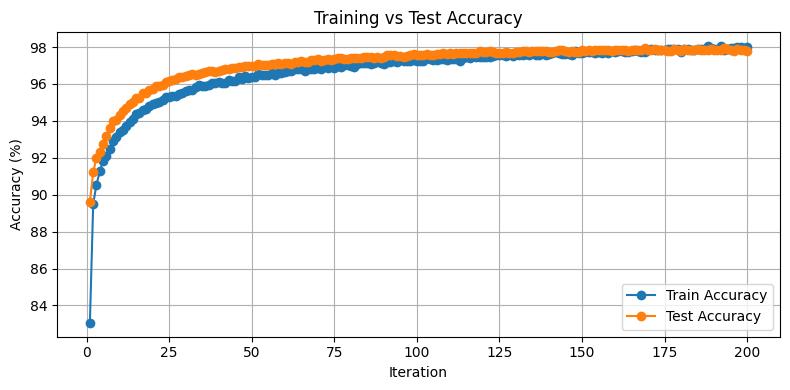

In [94]:
#save weights
save_weights(weights_0_1, weights_1_2)

# Plot Accuracy Curve
plot_accuracy(train_accs, test_accs)

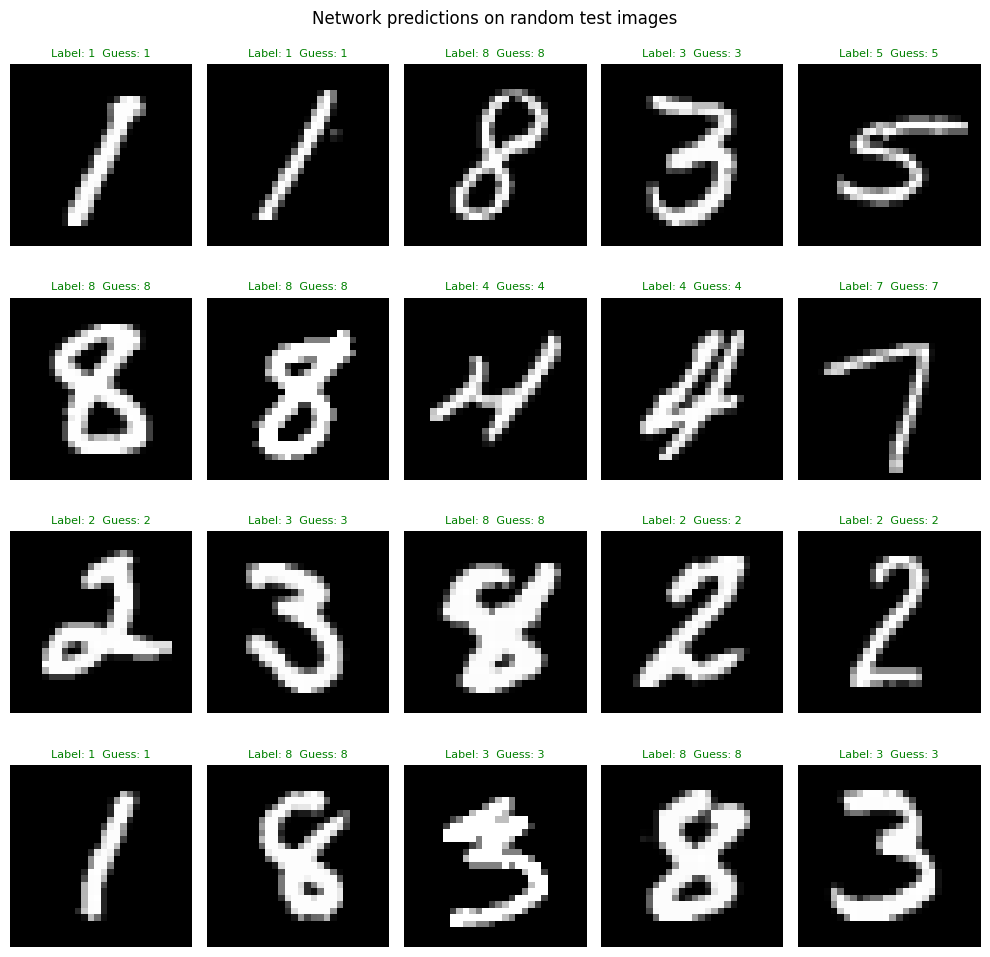

In [95]:
weights_0_1, weights_1_2 = load_weights()
# test on 20 digits
test_20_digit(weights_0_1, weights_1_2)